# Lab 1 Task 1

## 1. Implement the following layers as Python functions (both forward and backward propagation)
* Inner-product layer
* Activation layer(Sigmoid or Rectified)
* Softmax layer

In [14]:
import os
from typing import Callable, Iterable
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [15]:
class Parameter:
    def __init__(self, data: np.ndarray) -> None:
        self.data = data
        self.grad = None


class Module:
    def __call__(self, *args, **kwargs) -> np.ndarray:
        return self.forward(*args, **kwargs)

    def __repr__(self) -> str:
        layers = '\n'.join([f'  ({k}): {v}' for k, v in self.__dict__.items()])
        return f'{self.__class__.__name__}(\n{layers}\n)'

In [16]:
import numpy as np

class Linear(Module):
    def __init__(self, in_features, out_features) -> None:
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        init_factor = 0.01
        self.W = Parameter(np.random.randn(in_features, out_features) * init_factor)
        self.b = Parameter(np.zeros((1, out_features)))

        self.x = None  # cache input

    def forward(self, x):
        self.x = x
        return x @ self.W.data + self.b.data  # (N, in) @ (in, out) + (1, out) -> (N, out)

    def backward(self, dy):
        # dy: (N, out)
        # grads
        dW = self.x.T @ dy                         # (in, N) @ (N, out) -> (in, out)
        db = np.sum(dy, axis=0, keepdims=True)     # (1, out)
        dEdx = dy @ self.W.data.T                  # (N, out) @ (out, in) -> (N, in)

        # write/accumulate grads
        self.W.grad = dW if getattr(self.W, "grad", None) is None else self.W.grad + dW
        self.b.grad = db if getattr(self.b, "grad", None) is None else self.b.grad + db

        return dEdx

    def parameters(self):
        return self.W, self.b

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}(in_features={self.in_features}, out_features={self.out_features})'


class ReLU(Module):
    def __init__(self) -> None:
        super().__init__()
        self.x = None

    def forward(self, x):
        self.x = x
        return np.maximum(0, x)

    def backward(self, dy):
        return dy * (self.x > 0).astype(self.x.dtype)

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}()'


class Sigmoid(Module):
    def __init__(self) -> None:
        super().__init__()
        self.y = None  # cache output

    def forward(self, x):
        # numerically stable-ish sigmoid
        self.y = 1.0 / (1.0 + np.exp(-x))
        return self.y

    def backward(self, dy):
        # dσ/dx = σ(x) * (1 - σ(x))
        return dy * self.y * (1.0 - self.y)

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}()'


class Softmax(Module):
    def __init__(self) -> None:
        super().__init__()
        self.y = None  # cache output

    def forward(self, x):
        # stable softmax
        x_shift = x - np.max(x, axis=-1, keepdims=True)
        exp_x = np.exp(x_shift)
        self.y = exp_x / np.sum(exp_x, axis=-1, keepdims=True)
        return self.y

    def backward(self, dy):
        # General JVP for softmax: dE/dx = y * (dy - sum(dy * y))
        # Works per-sample across last axis
        dot = np.sum(dy * self.y, axis=-1, keepdims=True)
        return self.y * (dy - dot)

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}()'


In [17]:
class MLP(Module):
    def __init__(self, in_features, hidden1, hidden2, out_features):
        super().__init__()
        self.fc1 = Linear(in_features, hidden1)
        self.act1 = ReLU()
        self.fc2 = Linear(hidden1, hidden2)
        self.act2 = ReLU()
        self.fc3 = Linear(hidden2, out_features)

    def forward(self, x):
        h1 = self.fc1.forward(x)
        a1 = self.act1.forward(h1)
        h2 = self.fc2.forward(a1)
        a2 = self.act2.forward(h2)
        out = self.fc3.forward(a2)
        return out

    def backward(self, dy):
        d2 = self.fc3.backward(dy)
        d2 = self.act2.backward(d2)
        d1 = self.fc2.backward(d2)
        d1 = self.act1.backward(d1)
        dx = self.fc1.backward(d1)
        return dx

    def parameters(self):
        return (self.fc1.parameters() +
                self.fc2.parameters() +
                self.fc3.parameters())


## 2. Implement training and testing process
* included cross-validation

In [18]:
class MNIST:
    # root請根據你的檔案位置更改
    def __init__(self, root='../data', train=True, transform: Callable = None) -> None:
        path = os.path.join(root, 'mnist_train.csv' if train else 'mnist_test.csv')
        self.data = np.loadtxt(path, delimiter=',')
        self.transform = transform
        self.image_size = 28
        self.num_classes = 10
        self.classes = np.arange(self.num_classes)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        label = (self.data[idx, 0] == self.classes).astype(
            np.float32
        )  # one-hot encoding
        image = (
            self.data[idx, 1:]
            .reshape(self.image_size * self.image_size)
            .astype(np.float32)
        )
        if self.transform:
            image = self.transform(image)
        return image, label


class Subset:
    def __init__(self, dataset, indices: Iterable) -> None:
        self.dataset = dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.dataset[self.indices[idx]]


class DataLoader:
    def __init__(self, dataset, batch_size=1) -> None:
        self.dataset = dataset
        self.batch_size = batch_size
        self.indices = np.arange(len(dataset))

    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        for start_idx in range(0, len(self.dataset), self.batch_size):
            end_idx = min(start_idx + self.batch_size, len(self.dataset))
            batch_indices = self.indices[start_idx:end_idx]

            batch_images = []
            batch_labels = []

            for idx in batch_indices:
                image, label = self.dataset[idx]
                batch_images.append(image)
                batch_labels.append(label)

            yield np.array(batch_images), np.array(batch_labels)

In [19]:
from torch.utils.data import DataLoader, Subset, random_split
from torchvision.datasets import MNIST
import torch

def load_mnist_data(
    root="../data", batch_size=1, split_ratio=0.1, transform=None
) -> tuple[DataLoader, DataLoader, DataLoader]:
    def _split_dataset(dataset, split_ratio):
        # dataset size
        n = len(dataset)
        n_valid = int(n * split_ratio)
        n_train = n - n_valid

        # randomly split
        train_subset, valid_subset = random_split(
            dataset, [n_train, n_valid],
            generator=torch.Generator().manual_seed(42)  # for reproducibility
        )
        return train_subset, valid_subset

    trainset = MNIST(root=root, train=True, transform=transform, download=True)
    testset = MNIST(root=root, train=False, transform=transform, download=True)

    trainset, validset = _split_dataset(trainset, split_ratio=split_ratio)

    trainldr = DataLoader(trainset, batch_size=batch_size, shuffle=True)
    validldr = DataLoader(validset, batch_size=batch_size, shuffle=False)
    testldr = DataLoader(testset, batch_size=batch_size, shuffle=False)

    return trainldr, validldr, testldr


In [20]:
class CrossEntropyLoss(Module):
    def __init__(self, epsilon=1e-12) -> None:
        super().__init__()
        self.epsilon = epsilon
        self.probs = None
        self.targets = None

    def forward(self, logits, targets):
        """
        logits: (N, C) raw scores
        targets: (N,) int labels 0~C-1
        """
        # softmax (數值穩定)
        exp_x = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        self.probs = exp_x / np.sum(exp_x, axis=1, keepdims=True)

        self.targets = targets
        N = logits.shape[0]
        loss = -np.log(self.probs[np.arange(N), targets] + self.epsilon).mean()
        return loss

    def backward(self):
        N, C = self.probs.shape
        grad = self.probs.copy()
        grad[np.arange(N), self.targets] -= 1
        grad /= N
        return grad



class SGD:
    def __init__(self, params: Iterable, lr: float = 1e-3) -> None:
        self.params = params
        self.lr = lr

    def step(self):
        for param in self.params:
            if param.grad is not None:
                param.data -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.fill(0)

In [21]:
def train_one_epoch(model: Module, trainldr: Iterable, criterion, optimizer) -> tuple[float, float]:
    total = 0
    correct = 0
    total_loss = 0.0

    for x, y in tqdm(trainldr):
        # --- 資料處理 ---
        # (N,1,28,28) -> (N,784)，轉 numpy
        x = x.view(x.size(0), -1).detach().cpu().numpy()
        y = y.detach().cpu().numpy().astype(np.int64)   # 確保是整數類別

        # --- forward ---
        logits = model.forward(x)

        # --- loss ---
        loss = criterion.forward(logits, y)
        total_loss += float(loss) * len(y)

        # --- accuracy ---
        preds = np.argmax(logits, axis=1)
        correct += int((preds == y).sum())
        total += len(y)

        # --- backward ---
        dy = criterion.backward()
        _ = model.backward(dy)

        # --- update ---
        optimizer.step()
        optimizer.zero_grad()

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model: Module, testldr: Iterable, criterion) -> tuple[float, float]:
    total = 0
    correct = 0
    total_loss = 0.0

    for x, y in tqdm(testldr):
        x = x.view(x.size(0), -1).detach().cpu().numpy()
        y = y.detach().cpu().numpy().astype(np.int64)

        # forward
        logits = model.forward(x)
        loss = criterion.forward(logits, y)
        total_loss += float(loss) * len(y)

        preds = np.argmax(logits, axis=1)
        correct += int((preds == y).sum())
        total += len(y)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def train(model: MLP, trainldr: Iterable, validldr: Iterable, epochs=10, lr=1e-3):
    criterion = CrossEntropyLoss()             # 初始化一次
    optimizer = SGD(model.parameters(), lr=lr)

    train_loss, train_acc = [], []
    valid_loss, valid_acc = [], []

    for epoch in range(epochs):
        # --- train ---
        loss, acc = train_one_epoch(model, trainldr, criterion, optimizer)
        train_loss.append(loss)
        train_acc.append(acc)
        print(f'epoch {epoch+1:d}: train_loss = {loss:.4f}, train_acc = {acc:.4f}')

        # --- validation ---
        loss, acc = evaluate(model, validldr, criterion)
        valid_loss.append(loss)
        valid_acc.append(acc)
        print(f'epoch {epoch+1:d}: valid_loss = {loss:.4f}, valid_acc = {acc:.4f}\n')

    return train_loss, train_acc, valid_loss, valid_acc


In [22]:
def transform(x):
    """map pixels information from range(0, 255) to range(0.01, 1)"""
    return np.asarray(x) * 0.99 + 0.01

# "../data"請根據你的檔案位置更改
trainldr, validldr, testldr = load_mnist_data(
    "../data", batch_size=1, transform=transform
)
print(f"train set: {len(trainldr)} images")
print(f"validation set: {len(validldr)} images")
print(f"test set: {len(testldr)} images")
for x, y in trainldr:
    print(f"x shape: {x.shape}")
    print(f"y shape: {y.shape}")
    break

net = MLP(in_features=784,hidden1=256 ,hidden2=128, out_features=10)
print(net)
# 你可以調整 epochs 和 lr 來觀察不同的訓練效果
train_loss, train_acc, valid_loss, valid_acc = train(
    net, trainldr, validldr, epochs=8, lr=0.0001
)

train set: 54000 images
validation set: 6000 images
test set: 10000 images
x shape: torch.Size([1, 28, 28])
y shape: torch.Size([1])
MLP(
  (fc1): Linear(in_features=784, out_features=256)
  (act1): ReLU()
  (fc2): Linear(in_features=256, out_features=128)
  (act2): ReLU()
  (fc3): Linear(in_features=128, out_features=10)
)


100%|██████████| 54000/54000 [00:37<00:00, 1434.08it/s]


epoch 1: train_loss = 0.2770, train_acc = 0.9186


100%|██████████| 6000/6000 [00:00<00:00, 7785.44it/s]


epoch 1: valid_loss = 0.1463, valid_acc = 0.9565



...

epoch 7: valid_loss = 0.0831, valid_acc = 0.9763



100%|██████████| 54000/54000 [00:36<00:00, 1473.19it/s]


epoch 8: train_loss = 0.0165, train_acc = 0.9952


100%|██████████| 6000/6000 [00:00<00:00, 7866.10it/s]

epoch 8: valid_loss = 0.0773, valid_acc = 0.9800



In [23]:
# Using test_images and test_labels to do the final test
criterion = CrossEntropyLoss()
test_loss, test_acc = evaluate(net, testldr, criterion)
print(f"test_loss = {test_loss}, test_acc = {test_acc}")

100%|██████████| 10000/10000 [00:01<00:00, 7910.38it/s]

test_loss = 0.07130960087069783, test_acc = 0.9804


## 3. Plot loss & accuracy curves(both Training and Validation)

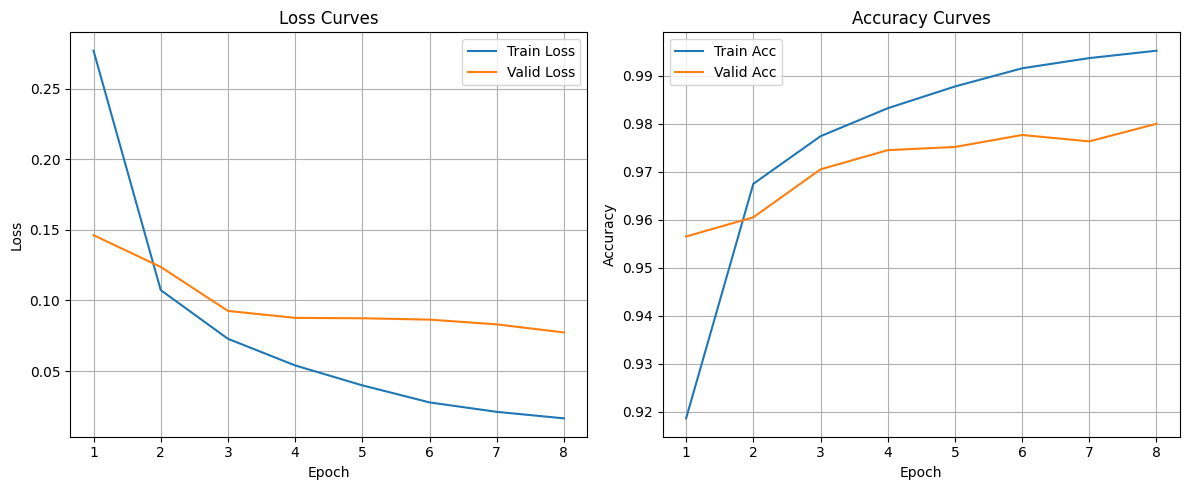

In [24]:

import matplotlib.pyplot as plt

def plot_curves(train_loss, valid_loss, train_acc, valid_acc):
    epochs = range(1, len(train_loss) + 1)

    # --- Loss curves ---
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, valid_loss, label="Valid Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curves")
    plt.legend()
    plt.grid(True)

    # --- Accuracy curves ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Acc")
    plt.plot(epochs, valid_acc, label="Valid Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curves")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_curves(train_loss, valid_loss, train_acc, valid_acc)